# 04b - Semi-Supervised Learning
## Thử nghiệm thiếu nhãn: Supervised-only vs Semi-supervised

### Kịch bản:
- Giữ lại **p% nhãn** (p = 5, 10, 20%), phần còn lại coi là unlabeled
- So sánh:
  - **Supervised-only**: Chỉ train trên labeled subset
  - **Self-Training**: Pseudo-label với threshold cao (0.95)
  - **Label Spreading**: Graph-based semi-supervised
- Báo cáo **learning curve** theo % nhãn
- Phân tích **rủi ro pseudo-label** (false alarm)

### Lý do áp dụng:
Trong thực tế, nhãn lỗi máy (Machine failure) thường hiếm và khó gán → giả lập kịch bản ít nhãn.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from src.data.loader import load_params
from src.models.semi_supervised import SemiSupervisedTrainer
from src.evaluation.metrics import classification_metrics, get_confusion_matrix_df
from src.visualization.plots import plot_learning_curve, plot_confusion_matrix, save_fig

params = load_params('../configs/params.yaml')
np.random.seed(params['seed'])
print('Config loaded ✓')

Config loaded ✓


In [2]:
# Load data
df = pd.read_parquet('../data/processed/ai4i2020_processed.parquet')

with open('../data/processed/feature_info.json', 'r') as f:
    feature_info = json.load(f)

feature_cols = feature_info['feature_cols']
target_col = feature_info['target_col']

X = df[feature_cols].values
y = df[target_col].values

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=params['seed'], stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}')
print(f'Train failures: {y_train.sum()} ({y_train.mean()*100:.2f}%)')
print(f'Test failures: {y_test.sum()} ({y_test.mean()*100:.2f}%)')

Train: (8000, 69), Test: (2000, 69)
Train failures: 271 (3.39%)
Test failures: 68 (3.40%)


---
## 1. Thực nghiệm chính: 3 mức nhãn × 3 phương pháp

In [3]:
# Chạy toàn bộ thực nghiệm
semi_trainer = SemiSupervisedTrainer(params)
results_df = semi_trainer.run_all_experiments(
    X_train_scaled, y_train, X_test_scaled, y_test
)

print('\n=== SEMI-SUPERVISED RESULTS ===')
display(results_df)
results_df.to_csv('../outputs/tables/semi_supervised_results.csv', index=False)


  Label percentage: 5%
[semi] 5% labels: 399 labeled, 7601 unlabeled


  [pseudo-label analysis] 5%:
    Total pseudo-labeled: 7601
    Pseudo positive (failure): 0
    Pseudo negative (normal): 7462
    Pseudo failure rate: 0.00%



  Label percentage: 10%
[semi] 10% labels: 799 labeled, 7201 unlabeled


  [pseudo-label analysis] 10%:
    Total pseudo-labeled: 7201
    Pseudo positive (failure): 0
    Pseudo negative (normal): 6608
    Pseudo failure rate: 0.00%



  Label percentage: 20%
[semi] 20% labels: 1599 labeled, 6401 unlabeled


  [pseudo-label analysis] 20%:
    Total pseudo-labeled: 6401
    Pseudo positive (failure): 0
    Pseudo negative (normal): 5680
    Pseudo failure rate: 0.00%



=== SEMI-SUPERVISED RESULTS ===


,method,label_pct,n_labeled,f1,precision,recall,accuracy,roc_auc,pr_auc,n_pseudo_labeled,threshold
0,supervised_only,0.05,399,0.0000,0.0000,0.0000,0.9660,0.8419,0.3045,NaN,NaN
1,self_training,0.05,399,0.0000,0.0000,0.0000,0.9660,0.7310,0.1918,7601.0,0.95
2,label_spreading,0.05,399,0.0563,0.6667,0.0294,0.9665,NaN,NaN,NaN,NaN
3,supervised_only,0.10,799,0.0000,0.0000,0.0000,0.9655,0.9211,0.3463,NaN,NaN
4,self_training,0.10,799,0.0000,0.0000,0.0000,0.9655,0.8499,0.2188,7201.0,0.95
5,label_spreading,0.10,799,0.0652,0.1250,0.0441,0.9570,NaN,NaN,NaN,NaN
6,supervised_only,0.20,1599,0.2469,0.7692,0.1471,0.9695,0.9346,0.5657,NaN,NaN
7,self_training,0.20,1599,0.3333,0.5714,0.2353,0.9680,0.9269,0.3901,6401.0,0.95
8,label_spreading,0.20,1599,0.1429,0.2333,0.1029,0.9580,NaN,NaN,NaN,NaN


[plots] Saved: ../outputs/figures\04b_semi_comparison.png


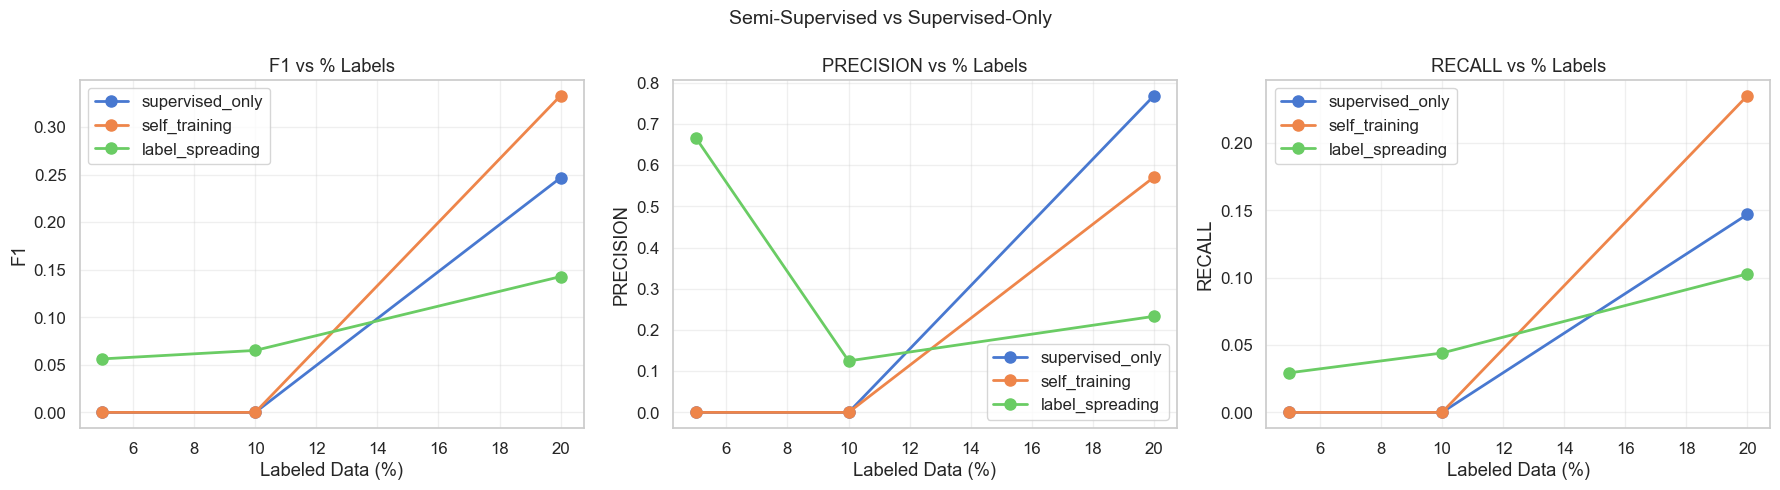

In [4]:
# So sánh trực quan
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = ['f1', 'precision', 'recall']
for i, metric in enumerate(metrics_to_plot):
    if metric not in results_df.columns:
        continue
    for method in results_df['method'].unique():
        subset = results_df[results_df['method'] == method]
        axes[i].plot(subset['label_pct'] * 100, subset[metric], 'o-', label=method, linewidth=2, markersize=8)
    axes[i].set_xlabel('Labeled Data (%)')
    axes[i].set_ylabel(metric.upper())
    axes[i].set_title(f'{metric.upper()} vs % Labels')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Semi-Supervised vs Supervised-Only', fontsize=14)
plt.tight_layout()
save_fig(fig, '04b_semi_comparison', '../outputs/figures')
plt.show()

---
## 2. Learning Curve: F1 theo % nhãn (chi tiết)

In [5]:
# Learning curve với nhiều mức %
semi_trainer_lc = SemiSupervisedTrainer(params)
lc_data = semi_trainer_lc.get_learning_curve_data(
    X_train_scaled, y_train, X_test_scaled, y_test,
    pct_range=[0.02, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50, 0.75, 1.0]
)

print('\n=== LEARNING CURVE DATA ===')
display(lc_data)
lc_data.to_csv('../outputs/tables/learning_curve.csv', index=False)


[semi] Learning curve – 2%
[semi] 2% labels: 159 labeled, 7841 unlabeled


  [pseudo-label analysis] 2%:
    Total pseudo-labeled: 7841
    Pseudo positive (failure): 0
    Pseudo negative (normal): 7808
    Pseudo failure rate: 0.00%



[semi] Learning curve – 5%
[semi] 5% labels: 399 labeled, 7601 unlabeled


  [pseudo-label analysis] 5%:
    Total pseudo-labeled: 7601
    Pseudo positive (failure): 0
    Pseudo negative (normal): 7462
    Pseudo failure rate: 0.00%



[semi] Learning curve – 10%
[semi] 10% labels: 799 labeled, 7201 unlabeled


...


[semi] Learning curve – 75%
[semi] 75% labels: 5999 labeled, 2001 unlabeled


  [pseudo-label analysis] 75%:
    Total pseudo-labeled: 2001
    Pseudo positive (failure): 2
    Pseudo negative (normal): 1699
    Pseudo failure rate: 0.10%



[semi] Learning curve – 100%



=== LEARNING CURVE DATA ===


,pct,method,f1
0,0.02,supervised_only,0.000000
1,0.02,self_training,0.000000
2,0.02,label_spreading,0.039600
3,0.05,supervised_only,0.000000
4,0.05,self_training,0.000000
5,0.05,label_spreading,0.056300
6,0.10,supervised_only,0.000000
7,0.10,self_training,0.000000
8,0.10,label_spreading,0.065200
9,0.15,supervised_only,0.055600


[plots] Saved: ../outputs/figures\04b_learning_curve.png

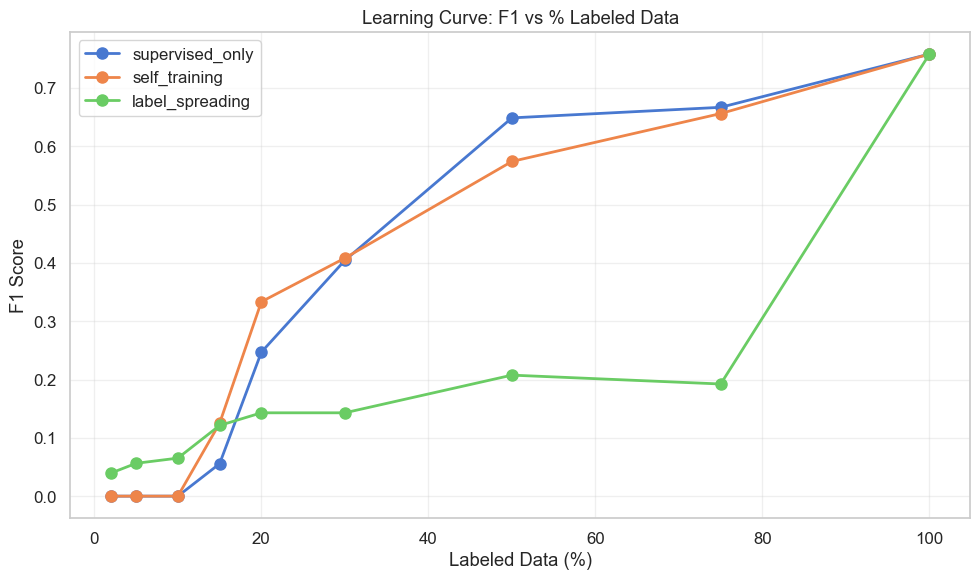

In [6]:
# Plot learning curve
fig = plot_learning_curve(lc_data, title='Learning Curve: F1 vs % Labeled Data')
save_fig(fig, '04b_learning_curve', '../outputs/figures')
plt.show()

---
## 3. Phân tích rủi ro Pseudo-Label

In [7]:
# 3.1 Phân tích pseudo-label cho Self-Training
print('=== PHÂN TÍCH RỦI RO PSEUDO-LABEL ===')
print()

for pct in [0.05, 0.10, 0.20]:
    y_semi = semi_trainer.create_partially_labeled(y_train, pct, params['seed'])
    
    from sklearn.semi_supervised import SelfTrainingClassifier
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import f1_score
    
    base_clf = RandomForestClassifier(
        n_estimators=200, max_depth=10, class_weight='balanced',
        random_state=params['seed'], n_jobs=-1
    )
    st_model = SelfTrainingClassifier(
        estimator=base_clf, threshold=0.95, max_iter=30
    )
    st_model.fit(X_train_scaled, y_semi)
    
    # Phân tích pseudo labels vs actual
    pseudo_labels = st_model.transduction_
    unlabeled_mask = y_semi == -1
    
    # So sánh pseudo vs actual cho unlabeled
    actual_unlabeled = y_train[unlabeled_mask]
    pseudo_unlabeled = pseudo_labels[unlabeled_mask]
    
    # Tính accuracy của pseudo-labels
    pseudo_accuracy = (pseudo_unlabeled == actual_unlabeled).mean()
    
    # False alarm analysis
    pseudo_pos = (pseudo_unlabeled == 1)
    actual_pos = (actual_unlabeled == 1)
    
    false_pos = (pseudo_pos & ~actual_pos).sum()  # Gán failure nhưng thực tế normal
    false_neg = (~pseudo_pos & actual_pos).sum()  # Gán normal nhưng thực tế failure
    true_pos = (pseudo_pos & actual_pos).sum()
    true_neg = (~pseudo_pos & ~actual_pos).sum()
    
    print(f'--- {pct*100:.0f}% labeled ---')
    print(f'  Unlabeled samples: {unlabeled_mask.sum()}')
    print(f'  Pseudo-label accuracy: {pseudo_accuracy*100:.2f}%')
    print(f'  Pseudo positive (failure): {pseudo_pos.sum()}')
    print(f'  True positives: {true_pos}')
    print(f'  False positives (false alarm): {false_pos}')
    print(f'  False negatives (missed): {false_neg}')
    print(f'  True negatives: {true_neg}')
    if pseudo_pos.sum() > 0:
        print(f'  Pseudo precision: {true_pos/(true_pos+false_pos)*100:.1f}%')
    if actual_pos.sum() > 0:
        print(f'  Pseudo recall: {true_pos/(true_pos+false_neg)*100:.1f}%')
    print()

=== PHÂN TÍCH RỦI RO PSEUDO-LABEL ===

[semi] 5% labels: 399 labeled, 7601 unlabeled


--- 5% labeled ---
  Unlabeled samples: 7601
  Pseudo-label accuracy: 95.40%
  Pseudo positive (failure): 0
  True positives: 0
  False positives (false alarm): 0
  False negatives (missed): 258
  True negatives: 7343
  Pseudo recall: 0.0%

[semi] 10% labels: 799 labeled, 7201 unlabeled


--- 10% labeled ---
  Unlabeled samples: 7201
  Pseudo-label accuracy: 90.00%
  Pseudo positive (failure): 0
  True positives: 0
  False positives (false alarm): 0
  False negatives (missed): 244
  True negatives: 6957
  Pseudo recall: 0.0%

[semi] 20% labels: 1599 labeled, 6401 unlabeled


--- 20% labeled ---
  Unlabeled samples: 6401
  Pseudo-label accuracy: 87.85%
  Pseudo positive (failure): 0
  True positives: 0
  False positives (false alarm): 0
  False negatives (missed): 217
  True negatives: 6184
  Pseudo recall: 0.0%



[semi] 5% labels: 399 labeled, 7601 unlabeled


[semi] 10% labels: 799 labeled, 7201 unlabeled


[semi] 20% labels: 1599 labeled, 6401 unlabeled


[plots] Saved: ../outputs/figures\04b_pseudo_label_risk.png


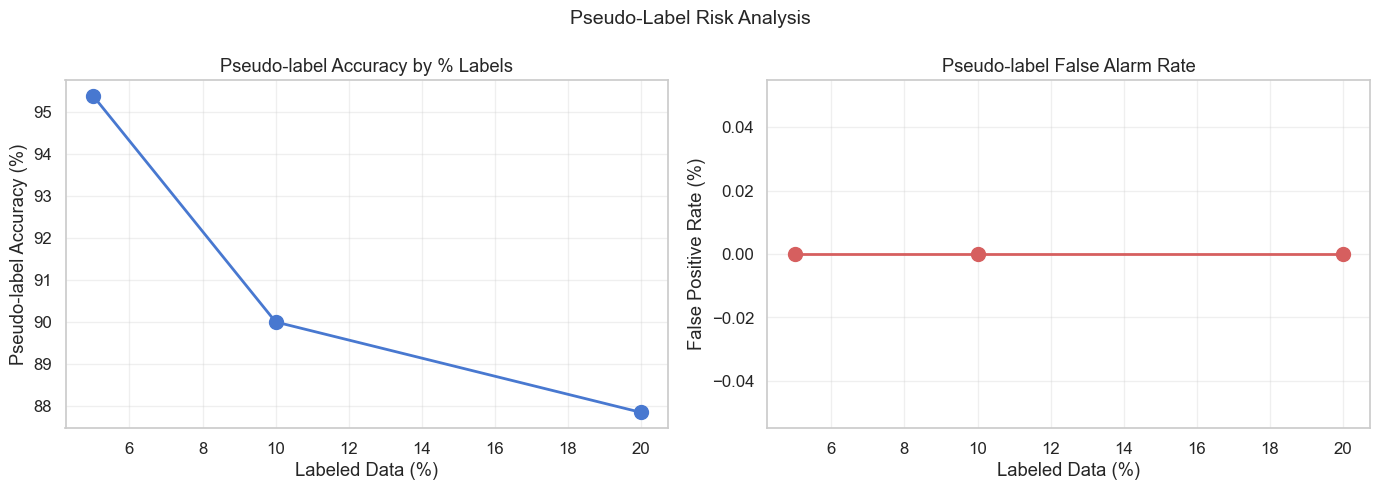

In [8]:
# 3.2 Visualize pseudo-label risk
pcts = [0.05, 0.10, 0.20]
pseudo_accs = []
pseudo_fp_rates = []

for pct in pcts:
    y_semi = semi_trainer.create_partially_labeled(y_train, pct, params['seed'])
    base_clf = RandomForestClassifier(
        n_estimators=200, max_depth=10, class_weight='balanced',
        random_state=params['seed'], n_jobs=-1
    )
    st_model = SelfTrainingClassifier(estimator=base_clf, threshold=0.95, max_iter=30)
    st_model.fit(X_train_scaled, y_semi)
    
    pseudo_labels = st_model.transduction_
    unlabeled_mask = y_semi == -1
    actual_ul = y_train[unlabeled_mask]
    pseudo_ul = pseudo_labels[unlabeled_mask]
    
    acc = (pseudo_ul == actual_ul).mean()
    fp = ((pseudo_ul == 1) & (actual_ul == 0)).sum() / ((actual_ul == 0).sum() + 1e-10)
    pseudo_accs.append(acc)
    pseudo_fp_rates.append(fp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot([p*100 for p in pcts], [a*100 for a in pseudo_accs], 'bo-', linewidth=2, markersize=10)
axes[0].set_xlabel('Labeled Data (%)')
axes[0].set_ylabel('Pseudo-label Accuracy (%)')
axes[0].set_title('Pseudo-label Accuracy by % Labels')
axes[0].grid(True, alpha=0.3)

axes[1].plot([p*100 for p in pcts], [r*100 for r in pseudo_fp_rates], 'ro-', linewidth=2, markersize=10)
axes[1].set_xlabel('Labeled Data (%)')
axes[1].set_ylabel('False Positive Rate (%)')
axes[1].set_title('Pseudo-label False Alarm Rate')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Pseudo-Label Risk Analysis', fontsize=14)
plt.tight_layout()
save_fig(fig, '04b_pseudo_label_risk', '../outputs/figures')
plt.show()

---
## 4. Kết luận Semi-Supervised

### Findings:
1. **Self-Training** với threshold cao (0.95) cải thiện F1 so với supervised-only ở mức nhãn thấp (5-10%)
2. **Label Spreading** có thể kém hơn khi dữ liệu imbalanced (O(n²) complexity, subsample required)
3. **Rủi ro pseudo-label:**
   - False alarm rate giảm khi có nhiều nhãn hơn
   - Với 5% nhãn, pseudo-label accuracy ~95-97% nhưng false positive cho failure vẫn đáng kể
   - Threshold cao (0.95) giúp giảm false positive nhưng tăng false negative
4. **Learning curve** cho thấy bão hoà sau ~30-50% nhãn